# Introduction to PyMCSimMod

The *PyMCSimMod* package can be used to define ordinary differential equation (ODE) models and solve initial value problems (IVPs) for such models. To define an ODE model, one first creates a “model specification” as a text string or a text file. (More details about the structure of the model specification text are provided in a separate vignette: “Model Specification”.) The model specification text can then be used to create a model object (i.e., an instance of the *PyMCSimMod* Model class) via the *PyMCSimMod* function `create_model()`.

Multiple backends can be supported for solving IVPs for a given model. The user can specify which backend to use when creating the model object. Currently supported backends include:
- SciPy (using `scipy.integrate.solve_ivp`)
- JAX (using `diffrax.diffeqsolve`)

Consider, for example, a simple ODE model given by
\begin{align}
  \frac{\textrm{d}}{\textrm{d}t}y(t) &= m, \\
  y(0) &= y_0.
\end{align}
We can create a model object corresponding to this ODE model using a text string that both provides the ODE for the state variable, $y$, and sets the (default) values of the model parameters to $y_0 = 2$ and $m = 0.5$.

First, we import  `create_model` from the **PyMCSimMod** package as follows.

In [1]:
%load_ext autoreload
%autoreload 2

from pymcsimmod import create_model

Then, we define the model string as follows.

In [2]:
mod_string = """
States = {
    y
};
y0 = 2;
m = 0.5;
Initialize {
    y = y0;
}
Dynamics {
    dt(y) = m;
}
End.
"""

Next, we create a `Model` object using the following command. This is where the backend is defined depending on which solver is desired to run the model. For a scipy model using `solve_ivp`, we set backend to `"scipy"`, while for a jax model using `diffeqsolve`, we set backend to `"jax"`.

In [3]:
model_scipy = create_model(mod_string, backend="scipy")
model_jax = create_model(mod_string, backend="jax")

Once the model is created with `create_model()`, all parameters and state variables can be accessed and modified via the model object.

We can examine the parameter values and initital conditions that are the defaults in the model object as follows.

In [4]:
print('The parameter dictionary is as follows:')
print(model_scipy.parameters)

print('The initial conditions dictionary is as follows:')
print(model_scipy.Y0)

The parameter dictionary is as follows:
{'y0': 2, 'm': 0.5}
The initial conditions dictionary is as follows:
{'y': 2}


We can also update the parameters

In [5]:
model_scipy.update_constants(m=1.0, y0=5.0)
print('The updated parameter dictionary is as follows:')
print(model_scipy.parameters)

print('The updated initial conditions dictionary is as follows:')
print(model_scipy.Y0)

The updated parameter dictionary is as follows:
{'y0': 5.0, 'm': 1.0}
The updated initial conditions dictionary is as follows:
{'y': 5.0}


Now we can run a simulation that provides results for the desired output times ($t = 0, 0.1, 0.2, \ldots, 20.0$) using the following commands. We will use the `arange` function from the `numpy` package to create the array of output times.

In [6]:
import numpy as np
times = np.arange(0, 20.1, 0.1)
result_scipy = model_scipy.run_model(times)

The result is a `ComputedModel` obeject that contains the simulation results and useful methods for post-processing the simulation.

Within the `ComputedModel` are the `times`, `states` (variables in the **States** block), and `aux_outputs` (variables in the **Outputs** block). These can be accessed individually, or through the final `dataframe` attribute that provides a pandas DataFrame with all results.

In [7]:
result_scipy.dataframe.head()

,time,y
0,0.0,5.0
1,0.1,5.1
2,0.2,5.2
3,0.3,5.3
4,0.4,5.4


Finally, we can create a visual representation of the simulation results. For example, we can plot the value of $y$ vs. time ($t$) using the following command.

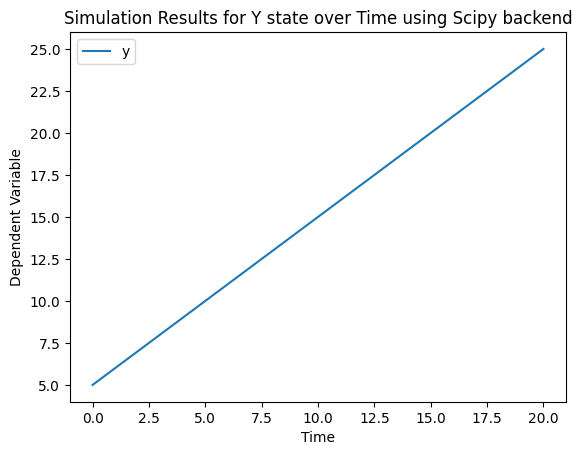

In [8]:
ax = result_scipy.plot_results(variables=['y'], xlabel='Time', ylabel='Dependent Variable')
_ = ax.set_title('Simulation Results for Y state over Time using Scipy backend')

The entire process works the same for a JAX model.

Using the previously defined `model_jax` object, we can run a simulation as follows.

In [9]:
result_jax = model_jax.run_model(times)

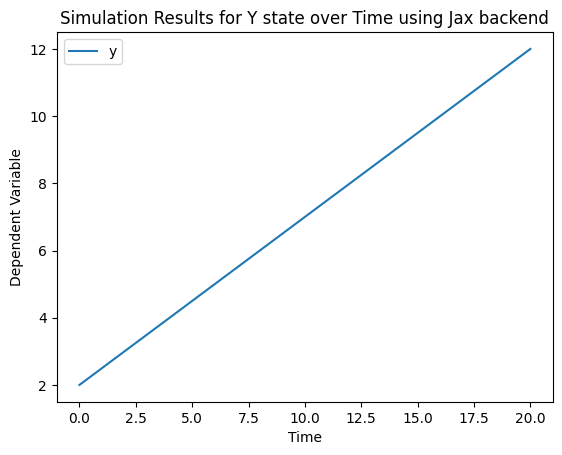

In [10]:
ax = result_jax.plot_results(variables=['y'], xlabel='Time', ylabel='Dependent Variable')
_ = ax.set_title('Simulation Results for Y state over Time using Jax backend')